In [16]:
# import cv2
# import numpy as np

# # Load the image
# ind = 1

# orig_image = "/Users/griffin/Documents/Data_Science_Projects/bhf_classification/data/train/train_" + str(ind).zfill(6) + ".png"
# image = cv2.imread(orig_image)
# h_img, w_img = image.shape[:2]  # Original image size


# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
# clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
# high_contrast = clahe.apply(gray)

# # Apply edge detection
# edges = cv2.Canny(high_contrast , 50, 150)

# # Find contours
# contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# document_contour = max(contours, key=cv2.contourArea)  # Get largest shape

# x, y, w, h = cv2.boundingRect(document_contour)

# # EXPAND the bounding box dynamically

# # **7️⃣ Apply Different Padding (0.1 for height, 0.2 for width)**
# height_padding = int(0.25 * h)  # 10% padding for height
# width_padding = int(0.001 * w)  # 20% padding for width

# # Adjust the bounding box with padding
# x_new = max(0, x - width_padding)
# y_new = max(0, y - height_padding)
# w_new = min(w_img, x + w + width_padding) - x_new
# h_new = min(h_img, y + h + height_padding) - y_new

# # Crop and save image
# cropped_document = image[y_new:y_new + h_new, x_new:x_new + w_new]
# cv2.imwrite("cropped_" + str(ind).zfill(6) + ".jpg", cropped_document)
# print("Cropped ECG document saved!")


In [ ]:
import cv2
import numpy as np

# Load the image
ind = 0

orig_image = "/Users/griffin/Documents/Data_Science_Projects/bhf_classification/data/train/train_" + str(ind).zfill(6) + ".png"
image = cv2.imread(orig_image)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
h_img, w_img = image.shape[:2]  # Original image size

# **1️⃣ Increase Contrast using CLAHE**
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
high_contrast = clahe.apply(gray)

# **2️⃣ Apply Edge Detection (Canny)**
edges = cv2.Canny(high_contrast, 50, 150)

# **3️⃣ Find Contours to Detect the Document**
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
document_contour = max(contours, key=cv2.contourArea)  # Find largest contour

# **4️⃣ Get the Document's Corners (Bounding Box)**
# Use minAreaRect to get a rotated bounding box (which gives us the 4 corners)
rect = cv2.minAreaRect(document_contour)
box = cv2.boxPoints(rect)
box = np.int0(box)  # Convert to integer points

# **5️⃣ Order the Corners: Top-left, Top-right, Bottom-right, Bottom-left**
# Sort the points based on their location
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect

# Order the points
ordered_corners = order_points(box)

# **6️⃣ Calculate the Target Size Dynamically Based on Transformed Corners**
# Define target points for perspective transformation
width = int(np.linalg.norm(ordered_corners[0] - ordered_corners[1]))  # Horizontal distance
height = int(np.linalg.norm(ordered_corners[0] - ordered_corners[3]))  # Vertical distance

# **7️⃣ Compute the Perspective Transform**
# Define the target rectangle (with padding for extra space)
target_points = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype="float32")

# Get the perspective transform matrix
M = cv2.getPerspectiveTransform(ordered_corners, target_points)

# Apply the perspective warp
warped_image = cv2.warpPerspective(image, M, (width, height))

# **8️⃣ Adjust the Final Size Based on the Transformed Corners**
# After the perspective transform, let's find the coordinates of the transformed corners.
# Now, calculate the new bounding box of the transformed image to ensure no clipping.
transformed_corners = cv2.perspectiveTransform(np.array([ordered_corners], dtype="float32"), M)[0]

# Get the min and max coordinates to find the bounding box for the final image
min_x = min(transformed_corners[:, 0])
max_x = max(transformed_corners[:, 0])
min_y = min(transformed_corners[:, 1])
max_y = max(transformed_corners[:, 1])

# Calculate the new width and height of the transformed image
new_width = int(max_x - min_x)
new_height = int(max_y - min_y)

# **9️⃣ Adjust the Warp Again if Necessary (Dynamic Adjustments)**
# If we need to add more padding, we can adjust new_width and new_height.
# For example, we can add a margin to the height and width dynamically.
padding_factor_width = 0.1
padding_factor_height = 0.2

new_width = int(new_width * (1 + padding_factor_width))
new_height = int(new_height * (1 + padding_factor_height))

# **10️⃣ Final Perspective Warp with Correct Dimensions**
# Update target points with the newly calculated width and height
target_points = np.array([[0, 0], [new_width - 1, 0], [new_width - 1, new_height - 1], [0, new_height - 1]], dtype="float32")
M_final = cv2.getPerspectiveTransform(ordered_corners, target_points)

# Apply the final perspective warp
final_warped_image = cv2.warpPerspective(image, M_final, (new_width, new_height))

# **11️⃣ Save or Display the Corrected Image**
cv2.imwrite("cropped_" + str(ind).zfill(6) + ".jpg", final_warped_image)

# Show the result (optional)
cv2.imshow("Corrected Image", final_warped_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

print("Image corrected for perspective with dynamic size adjustments!")


In [17]:
import cv2
import numpy as np

def scan_document(image_path, ind):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not load image")
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    h_img, w_img = image.shape[:2]

    # Increase Contrast using CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    high_contrast = clahe.apply(gray)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(high_contrast, (5, 5), 0)

    # Apply Edge Detection with stronger parameters
    edges = cv2.Canny(blurred, 75, 200)
    
    # Dilate edges to connect broken lines
    kernel = np.ones((5,5), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)

    # Find Contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        raise ValueError("No contours found")
    
    # Filter contours by area to avoid noise
    min_area = 0.1 * h_img * w_img  # Minimum 10% of image area
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    if not valid_contours:
        raise ValueError("No valid document contours found")
        
    # Find the largest contour
    document_contour = max(valid_contours, key=cv2.contourArea)

    # Approximate the contour with higher precision
    epsilon = 0.02 * cv2.arcLength(document_contour, True)
    approx = cv2.approxPolyDP(document_contour, epsilon, True)
    
    # If we get exactly 4 points, use them
    # Otherwise, use minAreaRect
    if len(approx) == 4:
        box = approx.reshape(4, 2)
    else:
        rect = cv2.minAreaRect(document_contour)
        box = cv2.boxPoints(rect)
    
    box = np.float32(box)

    def order_points(pts):
        rect = np.zeros((4, 2), dtype="float32")
        
        # Sort points based on y-coordinates
        sorted_by_y = pts[np.argsort(pts[:, 1])]
        
        # Top points (first two after sorting by y)
        top_points = sorted_by_y[:2]
        bottom_points = sorted_by_y[2:]
        
        # Sort top points by x coordinate
        rect[0] = top_points[np.argmin(top_points[:, 0])]  # top-left
        rect[1] = top_points[np.argmax(top_points[:, 0])]  # top-right
        
        # Sort bottom points by x coordinate
        rect[2] = bottom_points[np.argmax(bottom_points[:, 0])]  # bottom-right
        rect[3] = bottom_points[np.argmin(bottom_points[:, 0])]  # bottom-left
        
        return rect

    # Order the corners
    ordered_corners = order_points(box)
    
    # Calculate width and height
    # Use maximum of top/bottom and left/right sides
    width = int(max(
        np.linalg.norm(ordered_corners[0] - ordered_corners[1]),  # top edge
        np.linalg.norm(ordered_corners[2] - ordered_corners[3])   # bottom edge
    ))
    
    height = int(max(
        np.linalg.norm(ordered_corners[0] - ordered_corners[3]),  # left edge
        np.linalg.norm(ordered_corners[1] - ordered_corners[2])   # right edge
    ))

    # Add small padding (5 pixels) to prevent edge cutting
    padding = 5
    width += 2 * padding
    height += 2 * padding

    # Define destination points with padding
    dst_points = np.array([
        [padding, padding],
        [width - padding, padding],
        [width - padding, height - padding],
        [padding, height - padding]
    ], dtype="float32")

    # Get perspective transform
    M = cv2.getPerspectiveTransform(ordered_corners, dst_points)
    
    # Apply perspective transform
    warped = cv2.warpPerspective(image, M, (width, height))
    
    # Save the result
    cv2.imwrite(f"cropped_{str(ind).zfill(6)}.jpg", warped)
    
    return warped

# Usage
ind = 50
image_path = f"/Users/griffin/Documents/Data_Science_Projects/bhf_classification/data/train/train_{str(ind).zfill(6)}.png"
result = scan_document(image_path, ind)

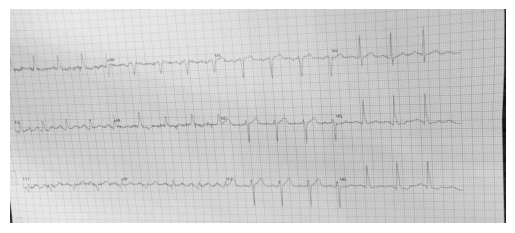

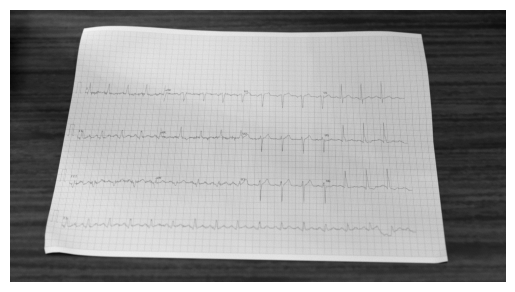

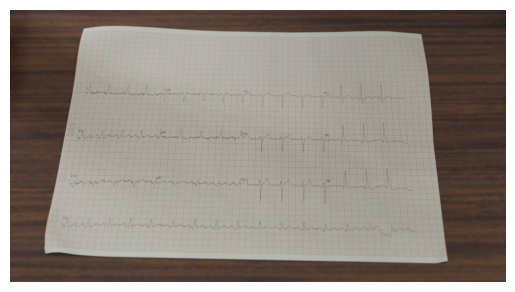

In [18]:
import matplotlib.pyplot as plt

# Read the image in RGB format (OpenCV loads in BGR by default)
cropped_document = cv2.imread("cropped_" + str(ind).zfill(6) + ".jpg")
cropped_document = cv2.cvtColor(cropped_document, cv2.COLOR_BGR2GRAY)

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(cropped_document, cmap = 'gray')
plt.axis("off")  # Hide axis
plt.show()

plt.imshow(gray, cmap='grey')
plt.axis("off")  # Hide axis
plt.show()

plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()
